[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RadimKozl/JLNN/blob/main/examples/JLNN_llm_rule_refinement.ipynb)

# **JLNN - Grand Cycle – Neuro-symbolic learning in a closed loop**

This tutorial introduces the advanced concept of the **Grand Cycle**, an architecture where statistical inference, interval logic, and the Large Language Model (LLM) are combined into a single autonomous system that learns and refines its knowledge base.

### ***Theoretical Introduction: The Three Pillars of the Grand Cycle***

#### ***1. Statistical Grounding (NumPyro)***

In classical logic, variables are either `True` or `False`. However, in the real world (e.g. in botany with the Iris dataset), the data is loaded with noise. **NumPyro** acts as the "eyes" of the system. Using Bayesian inference (NUTS sampler), we do not estimate just one number, but the entire probability distribution. The resulting **HDI (High Density Interval)** gives us the limits within which the truth lies with 95% certainty.

#### ***2. Interval logic (JLNN)***

**JLNN (JAX Logical Neural Network)** takes these statistical intervals as so-called **Grounding**. Unlike conventional neural networks, JLNN does not work with point estimates, but with entire intervals $[L,U]$.

- $L$ (Lower bound): Minimum confirmed truth (proof "for").
- $U$ (Upper bound): The maximum possible truth (everything that has not been disproved). The difference $U−L$ directly quantifies our **epistemic uncertainty**.

#### ***3. Cognitive refinement (deepseek-r1:1.5b)***

LLM (deepseek-r1:1.5b) does not work as a classic classifier here, but as a **meta-programmer**. It analyzes the results of logical inference and decides whether the existing rules are strong enough. If the logical gap is too wide, LLM suggests a new rule or adjusts the weight of the existing one, thereby autonomously rewriting the "software" (knowledge base) of the entire agent.

---------------------------------------------------------------------------

### ***Technical notes on implementation***

- **LNNFormula & Lark Parser:** JLNN uses the grammar defined in Lark to parse rules. The format `weight :: A -> B` allows you to define a so-called **Weighted Implication**. The higher the weight, the stricter the logical relationship.
- **Knowledge accumulation:** In each iteration, `current_rules` is expanded. At each step, the JLNN compiler rebuilds the computational graph, where old and new rules interact through shared nodes (e.g. `Is_Setosa`).
- **Stabilization via JAX:** The entire logic graph is compiled into XLA, ensuring high performance even with hundreds of rules. We force the CPU to run in Colab to avoid conflicts with the GPU memory used by Ollama to run Gemma.

### ***--- 1. INSTALLATION AND ENVIRONMENT CONFIGURATION ---***

In [ ]:
try:
    import jlnn
    import jraph
    import numpyro
    import ollama
    from flax import nnx
    import jax.numpy as jnp
    import numpy as np
    import xarray as xr
    import pandas as pd
    import qutip as qt
    import optuna
    import matplotlib.pyplot as plt
    import sklearn
    print("✅ JLNN and JAX are ready.")
except ImportError:
    print("🚀 Installing JLNN from GitHub and fixing JAX for Colab...")
    # Instalace frameworku
    #!pip install jax-lnn --quiet
    !pip install git+https://github.com/RadimKozl/JLNN.git --quiet
    !pip install optuna optuna-dashboard pandas scikit-learn matplotlib --quiet
    !pip install arviz --quiet
    !pip install seaborn --quiet
    !pip install numpyro jraph --quiet
    !pip install qutip --quiet
    !pip install ollama --quiet
    # Fix JAX/CUDA compatibility for 2026 in Colab
    !pip install --upgrade "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --quiet
    !pip install  scikit-learn pandas --quiet

    import os
    print("\n🔄 RESTARTING ENVIRONMENT... Please wait a second and then run the cell again.")
    os.kill(os.getpid(), 9)
    os.kill(os.getpid(), 9) # After this line, the cell stops and the environment restarts

🚀 Installing JLNN from GitHub and fixing JAX for Colab...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 912.3 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.7/516.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.3/83.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.5/180.5 

In [1]:
import os, sys
# for solving collision of CPU for Numpyro, JLNN and GPU for ollama

os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_SKIP_PJRT_C_API_GPU"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

### ***Installing system dependencies and Ollam***

In [2]:
print("📥 Installing system dependencies...")
!sudo apt update && sudo apt install pciutils zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

📥 Installing system dependencies...
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/univers

### ***Imports***

In [3]:
import subprocess
import jax
import re
import time
import jax.numpy as jnp
from jax import random
from flax import nnx
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
import ollama
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import threading
import time

from jlnn.symbolic.compiler import LNNFormula


In [4]:
numpyro.set_platform("cpu")
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

### ***--- 2. LAUNCHING OLLAM AND DOWNLOADING THE GEMMA 3 MODEL ---***

In [5]:
OLLAMA_MODEL = 'deepseek-r1:1.5b' # gemma3:4b, deepseek-r1:1.5b, llama3.2:3b, qwen3:1.7b
os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'
os.environ['OLLAMA_ORIGINS'] = '*'

In [6]:
def start_ollama_server():
    """Starts the Ollama server in the background."""
    try:
        subprocess.Popen(['ollama', 'serve'])
        print("🚀 Ollama server launched!")
    except Exception as e:
        print(f"Error starting Ollama server: {e}")

In [7]:
def pull_ollama_model(model_name):
    """Downloads the specified model after a short delay."""
    time.sleep(10) # Longer pause for server start
    print(f"⬇️ Starting to download model: {model_name} (this may take a few minutes)...")
    try:
        result = subprocess.run(f"ollama pull {model_name}", shell=True, check=True, capture_output=True, text=True)
        print(f"✅ Model {model_name} successfully downloaded!")
    except subprocess.CalledProcessError as e:
        print(f"❌ Error downloading model {model_name}:\n{e.stderr}")

In [10]:
threading.Thread(target=start_ollama_server).start()
time.sleep(10) # Longer pause for server start
threading.Thread(target=pull_ollama_model, args=(OLLAMA_MODEL,)).start()

🚀 Ollama server launched!
✅ Model deepseek-r1:1.5b successfully downloaded!


In [11]:
!ollama list
print("\n⏳ Wait for confirmation: '✅ Model successfully downloaded!'")

NAME                ID              SIZE      MODIFIED      
deepseek-r1:1.5b    e0979632db5a    1.1 GB    3 seconds ago    

⏳ Wait for confirmation: '✅ Model successfully downloaded!'


### ***--- 3. DATA PREPARATION (IRIS SETOSA) ---***

In [12]:
iris = load_iris()
# We will use Petal Length (index 2) and Sepal Width (index 1)
X_raw = iris.data[:, [2, 1]]
y_data = (iris.target == 0).astype(float) # Objective: Is it Setosa?

# Normalize to interval [0, 1]
X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)

### ***--- 4. STATISTICAL MODEL (NumPyro) ---***

We are looking for the optimal dividing point (threshold) for the length of the petal

In [13]:
def iris_interaction_model(data_x, data_y=None):
    """Statistical model with interaction between two traits."""
    # PetalLength (Probably small for Setosa)
    th_p = numpyro.sample("threshold_p", dist.Uniform(0.0, 1.0))
    st_p = numpyro.sample("steep_p", dist.Exponential(5.0))

    # SepalWidth (Probably wide for Setosa)
    th_s = numpyro.sample("threshold_s", dist.Uniform(0.0, 1.0))
    st_s = numpyro.sample("steep_s", dist.Exponential(5.0))

    # Interaction weight (allows the model to combine both features)
    w_inter = numpyro.sample("w_inter", dist.Beta(2.0, 2.0))

    # Fuzzy affiliation
    mem_p = jax.nn.sigmoid(st_p * (th_p - data_x[:, 0]))
    mem_s = jax.nn.sigmoid(st_s * (data_x[:, 1] - th_s))

    # Combination: linear mix between "Petal only" and "Petal AND Sepal"
    probs = (1 - w_inter) * mem_p + w_inter * (mem_p * mem_s)

    with numpyro.plate("data", data_x.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(probs=probs), obs=data_y)

### ***--- 5. LOGIC MODEL (JLNN + NNX) ---***

In [14]:
class BotanicalAgent(nnx.Module):
    """A logical agent processing a dynamic list of rules."""
    def __init__(self, rule_list, rngs: nnx.Rngs):
        # nnx.List is required for Flax/JAX compatibility
        self.formulas = nnx.List([LNNFormula(r, rngs=rngs) for r in rule_list])

    def __call__(self, grounding):
        # Gradual application of all rules
        outputs = [f(grounding) for f in self.formulas]
        return outputs[-1] # Return the result of the last (target) node

### ***--- 6. GRAND CYCLE EXECUTION ---***

In [15]:
def run_grand_cycle(model_name, max_iterations=5):
    """
    Autonomous Neuro-Symbolic Loop:
    Stats (NumPyro) -> Logic (JLNN) -> Reasoning (LLM)
    """
    # Initial knowledge base
    current_rules = ["0.85 :: PetalLength_Small -> Is_Setosa"]
    history = []

    # Definition of allowed atoms for validation
    allowed_atoms = ["PetalLength_Small", "PetalLength_Medium", "SepalWidth_Wide", "SepalWidth_Narrow", "Is_Setosa"]

    for iteration in range(1, max_iterations + 1):
        print(f"\n" + "="*60)
        print(f"🌀 GRAND CYCLE ITERATION {iteration}/{max_iterations}")
        print("="*60)

        # --- STEP 1: STATISTICAL GROUNDING (NumPyro) ---
        # (Assumes existing iris_interaction_model, X_scaled and y_data in namespace)
        mcmc = MCMC(NUTS(iris_interaction_model), num_samples=800, num_warmup=300, progress_bar=False)
        mcmc.run(jax.random.PRNGKey(iteration), data_x=X_scaled, data_y=y_data)
        samples = mcmc.get_samples()

        # HDI estimation for threshold values
        hdi_p = az.hdi(np.array(samples['threshold_p']), hdi_prob=0.95)
        hdi_s = az.hdi(np.array(samples['threshold_s']), hdi_prob=0.95)
        L_p, U_p, L_s, U_s = float(hdi_p[0]), float(hdi_p[1]), float(hdi_s[0]), float(hdi_s[1])

        # Calculation of the current Accuracy of the statistical model
        th_p_m, th_s_m = jnp.mean(samples['threshold_p']), jnp.mean(samples['threshold_s'])
        st_p_m, st_s_m = jnp.mean(samples['steep_p']), jnp.mean(samples['steep_s'])
        w_i_m = jnp.mean(samples['w_inter'])
        m_p = jax.nn.sigmoid(st_p_m * (th_p_m - X_scaled[:, 0]))
        m_s = jax.nn.sigmoid(st_s_m * (X_scaled[:, 1] - th_s_m))
        acc = accuracy_score(y_data, ((1 - w_i_m) * m_p + w_i_m * (m_p * m_s) > 0.5).astype(int))

        # --- STEP 2: LOGICAL INFERENCE (JLNN) ---
        # Create an agent with the current ruleset
        agent = BotanicalAgent(current_rules, nnx.Rngs(iteration))

        # Mapping statistical intervals to logical atoms
        grounding = {
            "PetalLength_Small":  jnp.array([[L_p, U_p]]),
            "PetalLength_Medium": jnp.array([[U_p, U_p + 0.15]]),
            "SepalWidth_Wide":    jnp.array([[L_s, U_s]]),
            "SepalWidth_Narrow":  jnp.array([[0.0, L_s]]),
            "Is_Setosa":          jnp.array([[0.0, 1.0]])
        }

        # Forward symbolic network (calculation of the truth interval for the target predicate)
        prediction = agent(grounding)
        res_L, res_U = float(prediction[0, -1, 0]), float(prediction[0, -1, 1])
        gap = res_U - res_L

        # --- STEP 3: LLM REFINEMENT (Anti-repetition and anti-hallucination strategies) ---

        # List of existing prompt formulas to avoid repeating LLM
        existing_kb_str = chr(10).join(current_rules)

        # --- PRE-PROCESSING FOR LLM ---
        # We create a list of purely logical structures without weights so that the model sees that they are forbidden
        forbidden_logic = [r.split("::")[1].split("->")[0].strip() for r in current_rules]

        # List of allowed atoms as a string for the prompt
        atoms_str = ", ".join(allowed_atoms[:-1]) # without Is_Setos

        report = f"""You are a Senior Logic Engineer for the JLNN neuro-symbolic system.
Your job is to propose precise, high-quality logical rules based on current performance.

THESE FORMULAS ARE ALREADY KNOWN AND FORBIDDEN (DO NOT REPEAT THEM):
Knowledge base:
{existing_kb_str}

Forbidden logic:
{chr(10).join(forbidden_logic)}

STATISTICS:
- Statistical Accuracy: {acc:.2%}
- Logical Epistemic Gap: {gap:.4f}

TASK:
Suggest ONE NEW COMPLEX RULE that is NOT in the list above.
Try to combine 2 or 3 atoms using '&' (AND) to create a more precise rule.

CRITICAL RULES FOR NEW RULE GENERATION:
1. If you suggest a formula like 'PetalLength_Small & SepalWidth_Wide', it is considered a DUPLICATE even if you use a different weight (e.g., 0.99 instead of 0.85).
2. You MUST change the logical structure (add/remove atoms, change operators).
3. A & B is the same as B & A. Be creative!
4. Use combinations of PetalLength_Medium, SepalWidth_Narrow, or use '|' (OR) to break the cycle.

ALLOWED ATOMS: {atoms_str}
ALLOWED OPERATORS: & | ->
TARGET: Is_Setosa

STRATEGY:
- If accuracy is flat, try a more specific rule (e.g., combining Petal and Sepal).
- Use weights between 0.70 and 0.98 based on your confidence.
- DO NOT suggest any formula that is already in the Current KB.

FORMAT:
Return **only one line** in exactly this format. No explanation, no quotes, no extra text.

weight :: formula -> Is_Setosa

Example of correct output:
0.93 :: PetalLength_Small & SepalWidth_Wide -> Is_Setosa

EXAMPLES OF GOOD RULES (different complexity levels):
0.85 :: PetalLength_Small -> Is_Setosa
0.92 :: PetalLength_Small & SepalWidth_Wide -> Is_Setosa
0.81 :: PetalLength_Medium | SepalWidth_Wide -> Is_Setosa
0.89 :: PetalLength_Small & SepalWidth_Narrow & PetalLength_Medium -> Is_Setosa
0.94 :: (PetalLength_Small & SepalWidth_Wide) -> Is_Setosa
0.75 :: (PetalLength_Small & SepalWidth_Narrow) | PetalLength_Medium -> Is_Setosa
"""

        print(f"🤖 {model_name} analyzing logical gaps...")
        new_rule = None

        for attempt in range(3):
            try:
                # Calling LLM
                resp = ollama.chat(model=model_name, messages=[{'role': 'user', 'content': report}])
                raw = resp['message']['content'].strip()

                print(f"   [Attempt {attempt+1}] LLM Raw Output: {raw}")

                # Extracting a rule using regex
                match = re.search(r'(\d*\.?\d+)\s*::\s*(.+?)\s*->\s*Is_Setosa', raw, re.IGNORECASE)

                if match:
                    weight, formula = match.group(1).strip(), match.group(2).strip()
                    candidate = f"{weight} :: {formula} -> Is_Setosa".replace('"', '').replace("'", "")

                    # Check if LLM has not used disallowed atoms (KeyError prevention)
                    found_atoms = re.findall(r'[a-zA-Z_]+', formula)
                    invalid_atoms = [a for a in found_atoms if a not in allowed_atoms]

                    if invalid_atoms:
                        print(f"   ❌ Rejected: Unknown atoms {invalid_atoms}")
                        continue

                    # Check if the rule is not already in the database (exact formula match)
                    if any(formula in r for r in current_rules):
                        print(f"   ❌ Rejected: Rule already exists in KB.")
                        continue

                    # Validation of syntactic correctness by JLNN parser
                    try:
                        LNNFormula(candidate, rngs=nnx.Rngs(0))
                        new_rule = candidate
                        print(f"   ✅ Accepted: {new_rule}")
                        break
                    except Exception as e:
                        print(f"   ❌ Parser rejected candidate -> {e}")
                        continue
                else:
                    print(f"   ⚠️ Regex failed: Output format incorrect.")
            except Exception as e:
                print(f"   ❌ LLM Error: {e}")

            time.sleep(1)

        # Knowledge base update
        if new_rule:
            current_rules.append(new_rule)
        else:
            print("⚠️ Iteration finished without a new rule (Keeping current KB).")

        # Save history with correct keys for visualization
        history.append({
            "iteration": iteration,
            "acc": acc,
            "gap": gap,
            "truth": (res_L, res_U),
            "rules": len(current_rules)
        })

    return history, current_rules

## ***5. VISUALIZATION OF DEVELOPMENT***

⬇️ Starting to download model: deepseek-r1:1.5b (this may take a few minutes)...

🌀 GRAND CYCLE ITERATION 1/8
✅ Model deepseek-r1:1.5b successfully downloaded!
🤖 deepseek-r1:1.5b analyzing logical gaps...
   [Attempt 1] LLM Raw Output: The new logical rule is constructed by combining medium-sized petals with wider sepals using an OR operator to ensure that Setosa flowers are included beyond those classified as Setosa through small petals alone.

**Answer:**  
(PetalLength_Medium | SepalWidth_Wide) & (PetalLength_Small | SepalWidth_Larger) → Is_Setosa
   ⚠️ Regex failed: Output format incorrect.
   [Attempt 2] LLM Raw Output: 0.92 :: (PetalLength_Medium & SepalWidth_Narrow) | (SepalWidth_Wide & PetalLength_Medium) -> Is_Setosa
   ✅ Accepted: 0.92 :: (PetalLength_Medium & SepalWidth_Narrow) | (SepalWidth_Wide & PetalLength_Medium) -> Is_Setosa

🌀 GRAND CYCLE ITERATION 2/8
🤖 deepseek-r1:1.5b analyzing logical gaps...
   [Attempt 1] LLM Raw Output: 0.85 :: (PetalLength_Small & SepalWidth_N

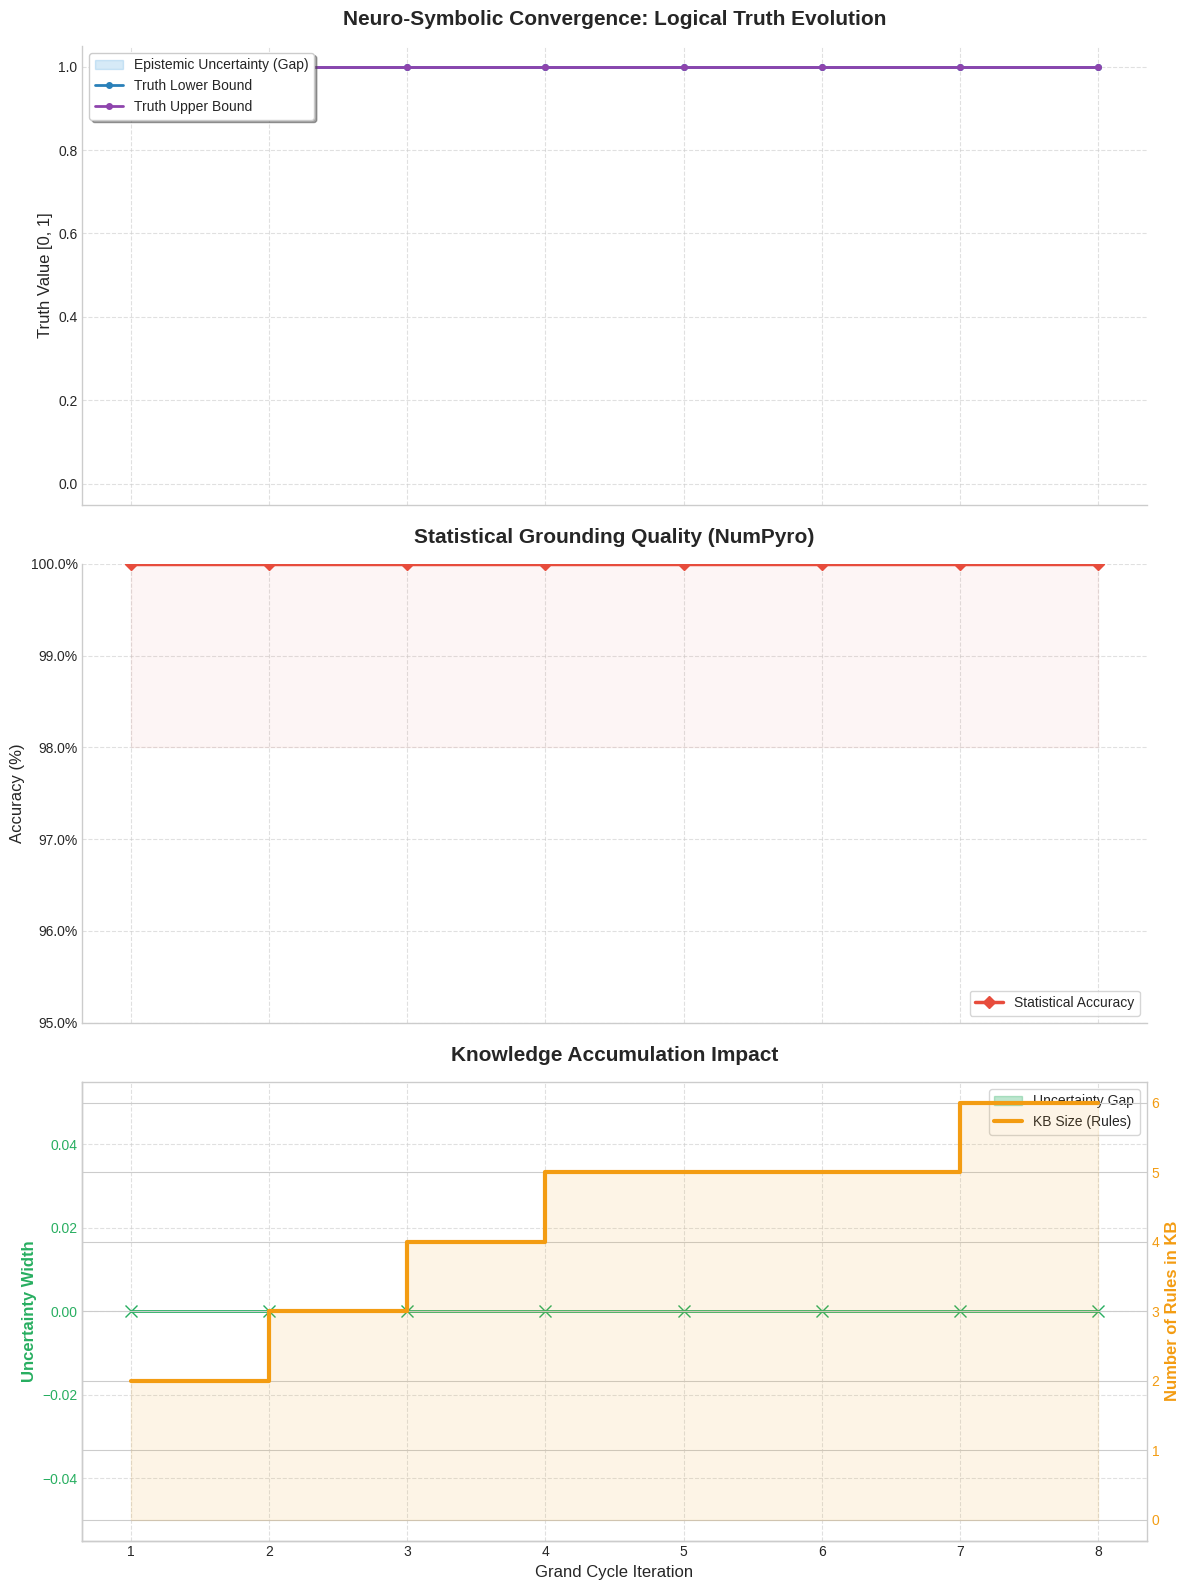


 🧠 FINAL SYMBOLIC KNOWLEDGE BASE
 Iter  0 | 0.85 :: PetalLength_Small -> Is_Setosa
 Iter  1 | 0.92 :: (PetalLength_Medium & SepalWidth_Narrow) | (SepalWidth_Wide & PetalLength_Medium) -> Is_Setosa
 Iter  2 | 0.85 :: (PetalLength_Small & SepalWidth_Narrow) -> Is_Setosa
 Iter  3 | 0.95 :: (PetalLength_Small | SepalWidth_Wide) -> Is_Setosa
 Iter  4 | 0.94 :: (PetalLength_Small & SepalWidth_Narrow) | (SepalWidth_Wide & PetalLength_Medium) -> Is_Setosa
 Iter  5 | 1.00 :: SepalWidth_Narrow | (PetalLength_Medium & SepalWidth_Wide) -> Is_Setosa


In [16]:
if __name__ == "__main__":
    # 1. START CALCULATION (we will save the result in 'history_data')
    # Make sure you have OLLAMA_MODEL defined
    history_data, final_kb = run_grand_cycle(model_name=OLLAMA_MODEL, max_iterations=8)

    # 2. DATA EXTRACTION
    iters       = [h['iteration'] for h in history_data]
    accs        = [h['acc']       for h in history_data]
    gaps        = [h['gap']       for h in history_data]
    truth_L     = [h['truth'][0]  for h in history_data]
    truth_U     = [h['truth'][1]  for h in history_data]
    rule_counts = [h['rules']     for h in history_data]

    # 3. VISUALIZATION (Improved "clean" look)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
    ax1, ax2, ax3 = axes

    # --- CHART 1: Evolution of logical truth ---
    ax1.fill_between(iters, truth_L, truth_U, color='#3498db', alpha=0.2, label='Epistemic Uncertainty (Gap)')
    ax1.plot(iters, truth_L, 'o-', color='#2980b9', linewidth=2, markersize=4, label='Truth Lower Bound')
    ax1.plot(iters, truth_U, 'o-', color='#8e44ad', linewidth=2, markersize=4, label='Truth Upper Bound')
    ax1.set_title('Neuro-Symbolic Convergence: Logical Truth Evolution', fontsize=15, pad=15, fontweight='bold')
    ax1.set_ylabel('Truth Value [0, 1]', fontsize=12)
    ax1.set_ylim(-0.05, 1.05)
    ax1.legend(loc='upper left', frameon=True, shadow=True)

    # --- CHART 2: Accuracy ---
    ax2.plot(iters, accs, color='#e74c3c', marker='D', linewidth=2.5, markersize=6, label='Statistical Accuracy')
    ax2.fill_between(iters, accs, min(accs)-0.02, color='#e74c3c', alpha=0.05)
    ax2.set_ylim(max(0, min(accs) - 0.05), min(1, max(accs) + 0.05))
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax2.set_title('Statistical Grounding Quality (NumPyro)', fontsize=15, pad=15, fontweight='bold')
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(loc='lower right', frameon=True)

    # --- CHART 3: KB growth vs. Gap ---
    color_gap = '#27ae60'
    color_rules = '#f39c12'
    ax3.fill_between(iters, gaps, color=color_gap, alpha=0.3, label='Uncertainty Gap')
    ax3.plot(iters, gaps, color=color_gap, linewidth=2, marker='x', markersize=8)
    ax3.set_ylabel('Uncertainty Width', color=color_gap, fontsize=12, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor=color_gap)

    ax3_twin = ax3.twinx()
    ax3_twin.step(iters, rule_counts, where='post', color=color_rules, linewidth=3, label='KB Size (Rules)')
    ax3_twin.fill_between(iters, rule_counts, step="post", color=color_rules, alpha=0.1)
    ax3_twin.set_ylabel('Number of Rules in KB', color=color_rules, fontsize=12, fontweight='bold')
    ax3_twin.tick_params(axis='y', labelcolor=color_rules)

    ax3.set_title('Knowledge Accumulation Impact', fontsize=15, pad=15, fontweight='bold')
    ax3.set_xlabel('Grand Cycle Iteration', fontsize=12)
    h1, l1 = ax3.get_legend_handles_labels()
    h2, l2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(h1+h2, l1+l2, loc='upper right', frameon=True)

    # Removing excess edges
    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.xticks(iters)
    plt.tight_layout()
    plt.show()

    # List of rules
    print(f"\n{'='*85}\n 🧠 FINAL SYMBOLIC KNOWLEDGE BASE\n{'='*85}")
    for i, rule in enumerate(final_kb):
        print(f" Iter {i:2d} | {rule}")